<a href="https://colab.research.google.com/github/dumbhuh/PCD/blob/main/Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kaustubhb999_tomatoleaf_path = kagglehub.dataset_download('kaustubhb999/tomatoleaf')

print('Data source import complete.')

Using Colab cache for faster access to the 'tomatoleaf' dataset.
Data source import complete.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

In [3]:
IMAGE_SIZE = 255
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 50

In [4]:
train_dir = "/kaggle/input/tomatoleaf/tomato/train/"
val_dir = "/kaggle/input/tomatoleaf/tomato/val/"

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [6]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

In [7]:
# Load Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True, seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [8]:
# Optimasi performa
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
# === Model CNN dengan Transfer Learning (Paling Direkomendasikan) ===
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)
base_model.trainable = False   # Freeze dulu

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4), # Increased dropout rate
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Added L2 regularization
    layers.Dropout(0.3), # Increased dropout rate
    layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.001)) # Added L2 regularization
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Diturunkan ke 1e-4
    loss='categorical_crossentropy', # atau binary_crossentropy/sparse_categorical_crossentropy
    metrics=['accuracy']
)

In [11]:
# 1. Pastikan variabel EPOCHS sudah diset ke 50 sebelum cell ini
EPOCHS = 50

# 2. Jalankan training tanpa rem otomatis (EarlyStopping)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        # EarlyStopping dihapus dari sini agar tidak berhenti di tengah jalan

        # ModelCheckpoint tetap dipertahankan untuk menyimpan model terbaik di sepanjang 50 epoch
        tf.keras.callbacks.ModelCheckpoint('best_cnn_tomato.h5', save_best_only=True)
    ]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.2228 - loss: 2.3996

313/313 ━━━━━━━━━━━━━━━━━━━━ 283s 305ms/step - accuracy: 0.3390 - loss: 2.1430 - val_accuracy: 0.6190 - val_loss: 1.5733
Epoch 2/50
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5643 - loss: 1.5898

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.5962 - loss: 1.4852 - val_accuracy: 0.7330 - val_loss: 1.1696
Epoch 3/50
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6523 - loss: 1.2992

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6765 - loss: 1.2319 - val_accuracy: 0.7790 - val_loss: 1.0000
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7155 - loss: 1.1164

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.7171 - loss: 1.0976 - val_accuracy: 0.8080 - val_loss: 0.8899
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7524 - loss: 1.0163

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.8710 - loss: 0.5684 - val_accuracy: 0.9170 - val_loss: 0.4777
Epoch 33/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8711 - loss: 0.5652 - val_accuracy: 0.9030 - val_loss: 0.4977
Epoch 34/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8748 - loss: 0.5597 - val_accuracy: 0.9070 - val_loss: 0.4951
Epoch 35/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8752 - loss: 0.5610 - val_accuracy: 0.9080 - val_loss: 0.4798
Epoch 36/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8789 - loss: 0.5480 - val_accuracy: 0.9150 - val_loss: 0.4889
Epoch 37/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8732 - loss: 0.5532 - val_accuracy: 0.9140 - val_loss: 0.4777
Epoch 38/50
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8729 - loss: 0.5406

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8734 - loss: 0.5487 - val_accuracy: 0.9190 - val_loss: 0.4693
Epoch 39/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8797 - loss: 0.5392 - val_accuracy: 0.9090 - val_loss: 0.4750
Epoch 40/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8786 - loss: 0.5396 - val_accuracy: 0.9070 - val_loss: 0.4781
Epoch 41/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8809 - loss: 0.5315 - val_accuracy: 0.9120 - val_loss: 0.4699
Epoch 42/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8823 - loss: 0.5299

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8784 - loss: 0.5379 - val_accuracy: 0.9150 - val_loss: 0.4668
Epoch 43/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8869 - loss: 0.5208 - val_accuracy: 0.9040 - val_loss: 0.4808
Epoch 44/50
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8906 - loss: 0.5162

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8853 - loss: 0.5233 - val_accuracy: 0.9170 - val_loss: 0.4476
Epoch 45/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8787 - loss: 0.5283 - val_accuracy: 0.9150 - val_loss: 0.4686
Epoch 46/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8830 - loss: 0.5250 - val_accuracy: 0.9050 - val_loss: 0.4739
Epoch 47/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8857 - loss: 0.5115

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8837 - loss: 0.5138 - val_accuracy: 0.9200 - val_loss: 0.4467
Epoch 48/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8842 - loss: 0.5138 - val_accuracy: 0.9190 - val_loss: 0.4488
Epoch 49/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8842 - loss: 0.5144 - val_accuracy: 0.9130 - val_loss: 0.4582
Epoch 50/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8846 - loss: 0.5135 - val_accuracy: 0.9170 - val_loss: 0.4606


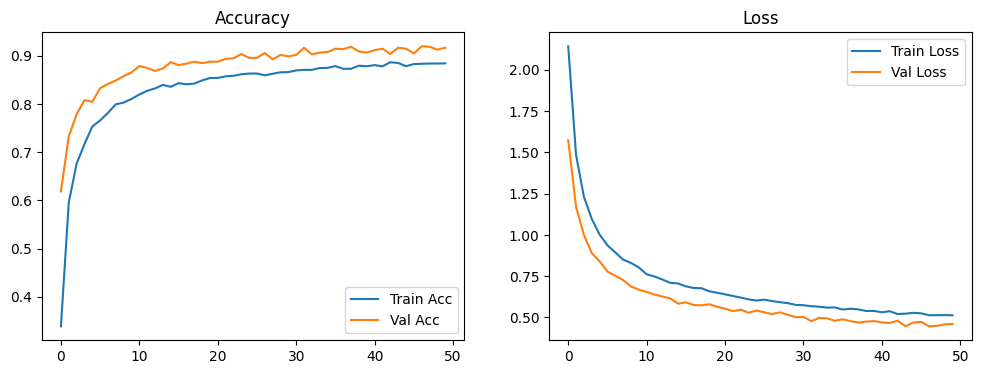

In [12]:
# Plot Training
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc'); plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.legend(); plt.title('Loss')
plt.show()